In [13]:
import matplotlib.pyplot as plt
import numpy as np

import yaml

from abacusnbody.metadata import get_meta

from pathlib import Path

In [3]:
with open('config_abacus.yaml', 'r') as f:
    config = yaml.safe_load(f)

sim_name = config['sim_params']['sim_name']
z = config['sim_params']['z_mock']

meta = get_meta(sim_name, redshift=z)
Lbox = meta['BoxSize']
z_ic = meta['InitialRedshift']
Ndim = int(meta['ppd'])


In [4]:
# load input linear power
kth = meta['CLASS_power_spectrum']['k (h/Mpc)']
pk_z1 = meta['CLASS_power_spectrum']['P (Mpc/h)^3']
D_ratio = meta['GrowthTable'][z] / meta['GrowthTable'][1.0]
p_m_lin = D_ratio**2 * pk_z1 # now it's at z

In [10]:
gen_power = np.loadtxt(config['power_spectrum']['linear'])
gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])

In [16]:
output_config = config['output']
output_dir = Path(output_config['directory'])/config['name']

sim_idx = 0

power_delta = np.load(output_dir/f'power_delta_{sim_idx:03}.npy', allow_pickle=True).item()
power_product = np.load(output_dir/f'power_product_{sim_idx:03}.npy', allow_pickle=True).item()
power_alt = np.load(output_dir/f'power_alt_{sim_idx:03}.npy', allow_pickle=True)



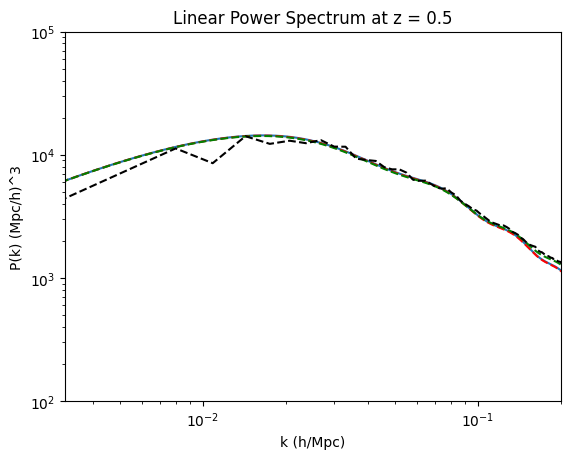

In [25]:
plt.loglog(kth, p_m_lin)

plt.plot(gen_power[:,0], gen_power[:,1], ls='--', c='r')

plt.plot(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

index = 1
plt.loglog(power_alt['k_avg'][:, index], power_alt['power'][:, index], ls = "--", c = "black")

plt.xlabel('k (h/Mpc)')
plt.ylabel('P(k) (Mpc/h)^3')
plt.title('Linear Power Spectrum at z = ' + str(z))


box = 2000
kmin_vol = 2*np.pi/box
plt.xlim(kmin_vol, 0.2)
plt.ylim(100, 1e5)
plt.show()


In [ ]:
array = numpy.fft.irfftn(array)
array[...] *= numpy.prod(array.shape) #complex array

In [ ]:
# average along projected axes;
        # part of product is the rfftn vs r2c (for axes)
        # the rest is for the mean (Nmesh - axes)
        c1 = numpy.fft.rfftn(r1) / self.attrs['Nmesh'].prod()